In [3]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sb
from sklearn.decomposition import PCA
import os

# EDA on SA

# Loading Dataset

In [4]:
mat_sa = sio.loadmat(r'C:\Users\asfia\OneDrive\Desktop\BSC Thesis\HSI-Thesis\data\Salinas.mat')
print(mat_sa.keys())

dict_keys(['__header__', '__version__', '__globals__', 'salinas'])


In [7]:
hsi_sa = mat_sa['salinas']

# Shape of the Dataset

In [ ]:
hsi_sa.shape #height=512,width=217,band=224

(512, 217, 224)

## Basic information

In [9]:
print('Datatype:',hsi_sa.dtype)
print('Maximum:',np.max(hsi_sa))
print('Minimum:',np.min(hsi_sa))
print('Mean:',np.mean(hsi_sa))
print('Std:',np.std(hsi_sa))

Datatype: int16
Maximum: 9207
Minimum: -14
Mean: 1090.1277882498766
Std: 1101.80257274481


## showing as RGB

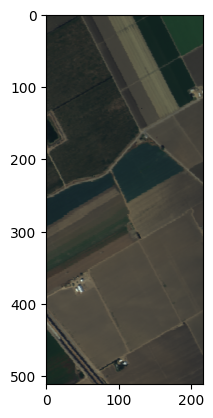

In [14]:
rgb_sa=hsi_sa[:,:,[30,20,10]]
rgb_sa=(rgb_sa-rgb_sa.min())/(rgb_sa.max()-rgb_sa.min())
plt.imshow(rgb_sa)
plt.show()

## Visualizing Individual Bands

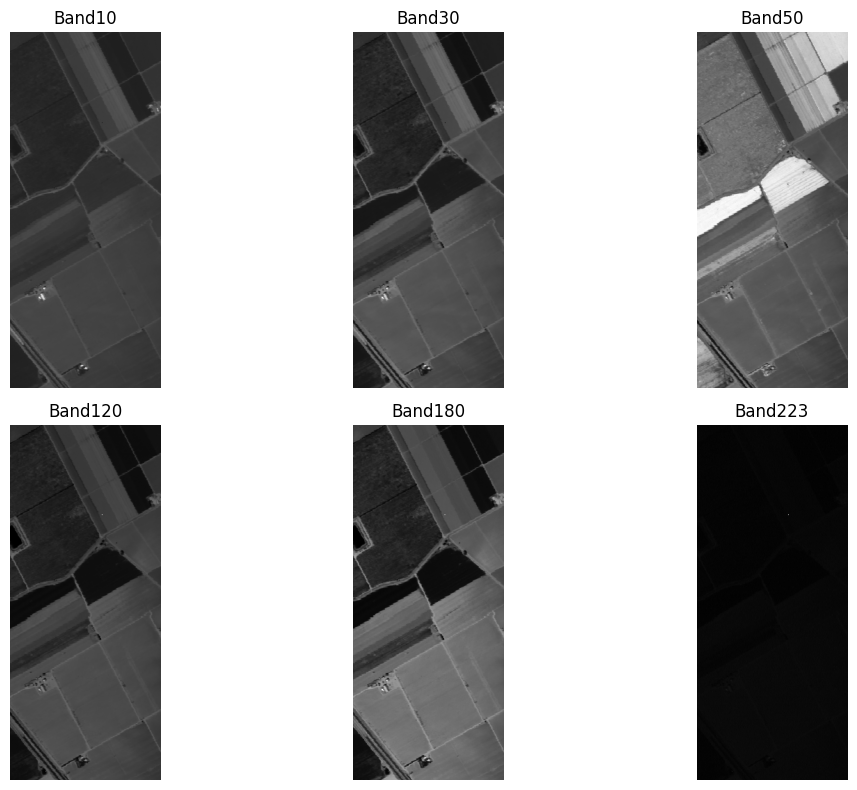

In [19]:
bands = [10,30,50,120,180,223]

plt.figure(figsize=(12,8))

for i,b in enumerate(bands):
    plt.subplot(2,3,i+1)
    plt.imshow(hsi_sa[:,:,b],cmap='grey')
    plt.title(f'Band{b}')
    plt.axis('off')
    
plt.tight_layout()
plt.show()

## Histogram of Pixel Values

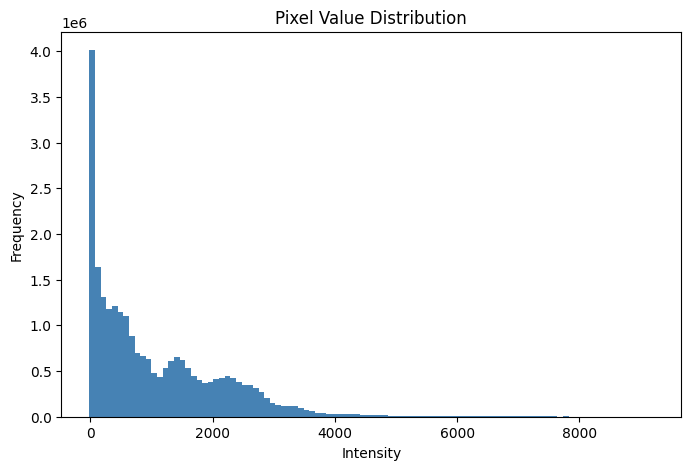

In [20]:
plt.figure(figsize=(8,5))

plt.hist(hsi_sa.flatten(),
         bins=100,
         color='steelblue')

plt.title('Pixel Value Distribution')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.show()

## Mean Intensity of Each Band

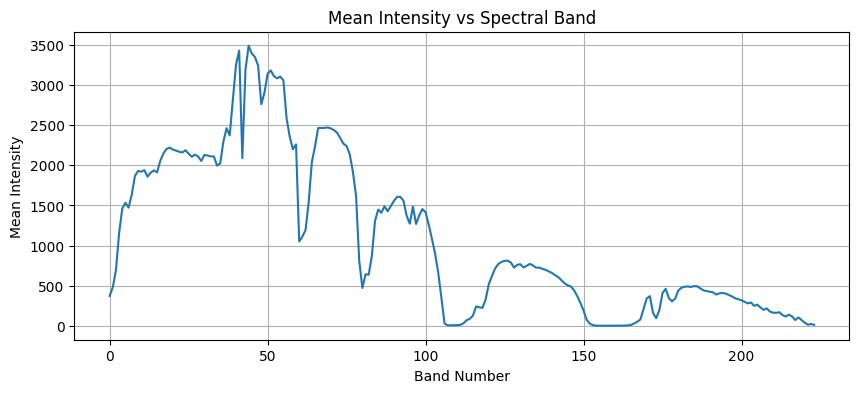

In [23]:
band_mean=np.mean(hsi_sa, axis=(0,1))

plt.figure(figsize=(10,4))
plt.plot(band_mean)
plt.xlabel('Band Number')
plt.ylabel('Mean Intensity')
plt.title('Mean Intensity vs Spectral Band')
plt.grid()
plt.show()

## Standard Deviation of Each Band

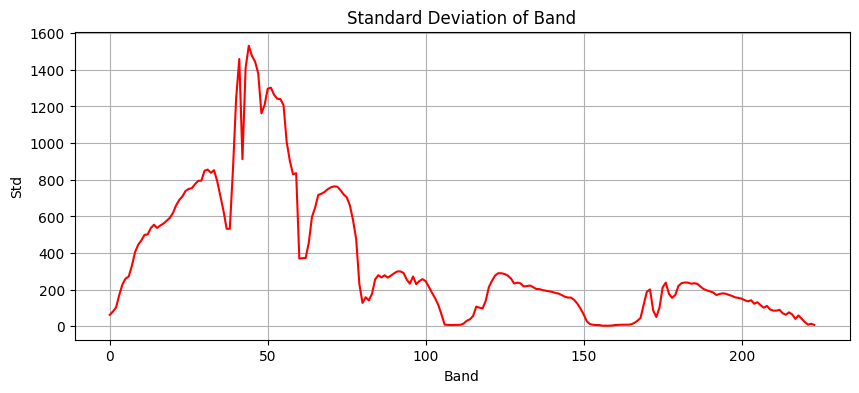

In [24]:
band_std=np.std(hsi_sa, axis=(0,1))

plt.figure(figsize=(10,4))
plt.plot(band_std, color='red')
plt.xlabel('Band')
plt.ylabel('Std')
plt.title('Standard Deviation of Band')
plt.grid()
plt.show()

## Spectral Signature

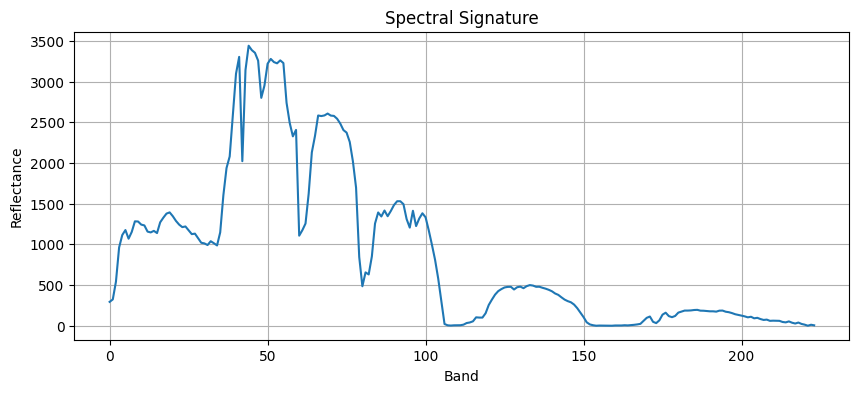

In [27]:
x=70
y=70

signature = hsi_sa[x,y,:]

plt.figure(figsize=(10,4))
plt.plot(signature)
plt.title("Spectral Signature")
plt.xlabel("Band")
plt.ylabel("Reflectance")
plt.grid()
plt.show()

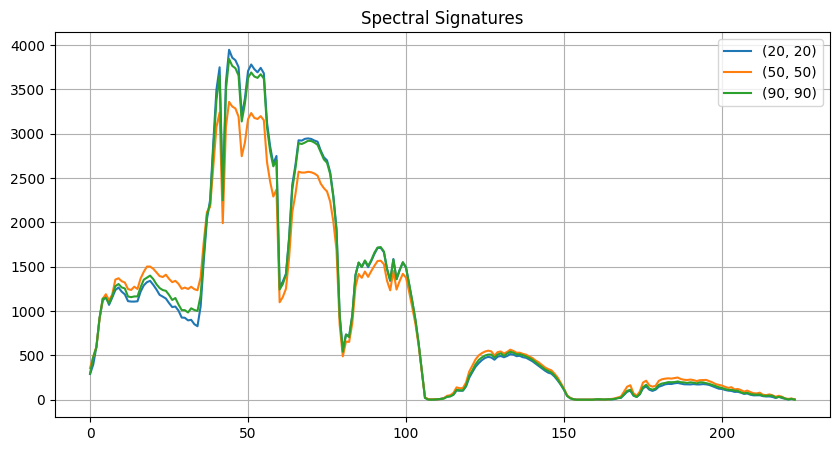

In [28]:
pixels=[(20,20),(50,50),(90,90)]

plt.figure(figsize=(10,5))

for p in pixels:
    plt.plot(hsi_sa[p[0],p[1],:],label=str(p))

plt.legend()
plt.grid()
plt.title("Spectral Signatures")
plt.show()

## Correlation Between Bands

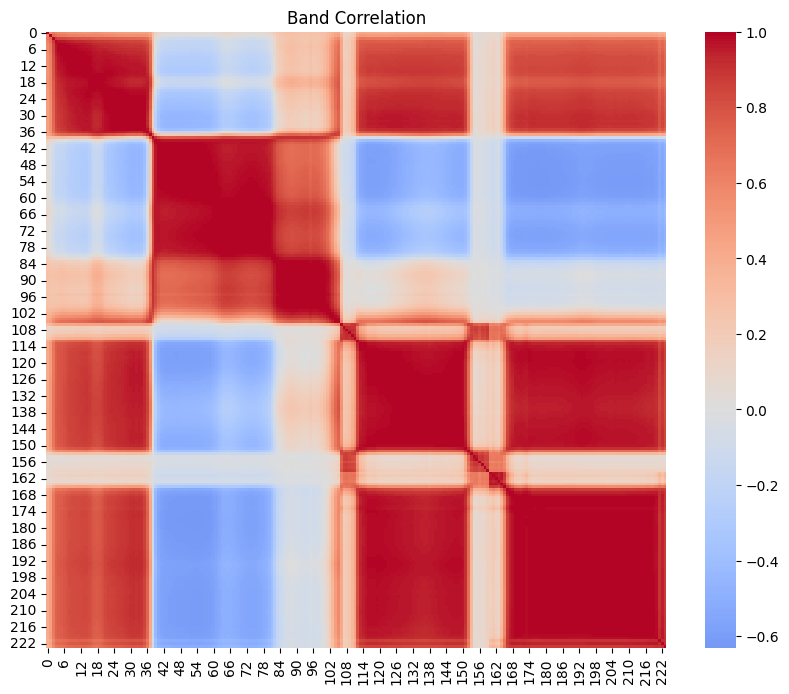

In [29]:
X = hsi_sa.reshape(-1,hsi_sa.shape[2])

corr = np.corrcoef(X.T)

plt.figure(figsize=(10,8))
sb.heatmap(corr, cmap='coolwarm',center=0)

plt.title("Band Correlation")
plt.show()

## PCA

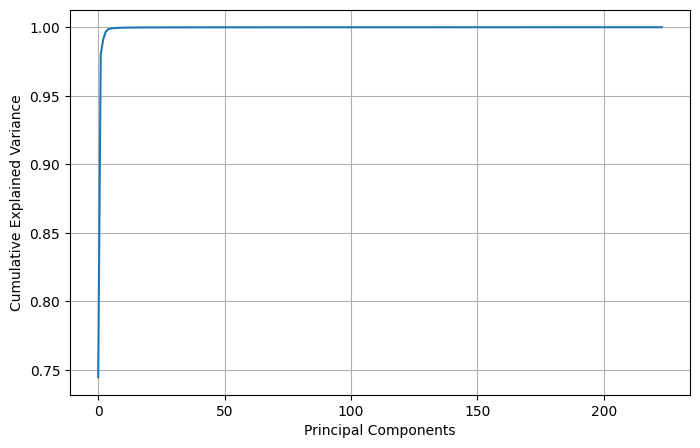

In [32]:
X = hsi_sa.reshape(-1,hsi_sa.shape[2])

pca = PCA()

pca.fit(X)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

## PCA Image

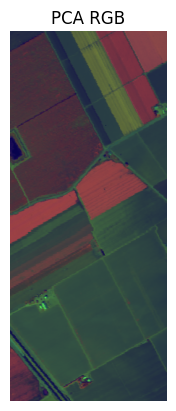

In [33]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X)

img = X_pca.reshape(hsi_sa.shape[0],hsi_sa.shape[1],3)

img = (img-img.min())/(img.max()-img.min())

plt.imshow(img)
plt.title("PCA RGB")
plt.axis("off")
plt.show()

## Noise Detection

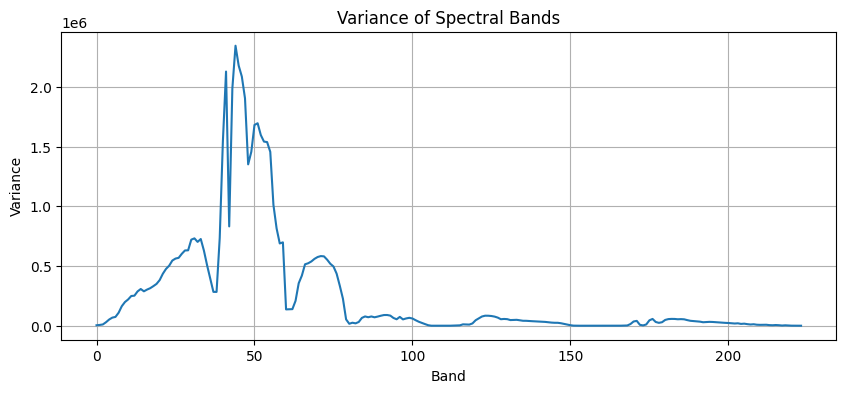

In [35]:
variance = np.var(hsi_sa,axis=(0,1))

plt.figure(figsize=(10,4))
plt.plot(variance)
plt.grid()
plt.title("Variance of Spectral Bands")
plt.xlabel("Band")
plt.ylabel("Variance")
plt.show()

## Missing Values

In [36]:
print("NaN values :", np.isnan(hsi_sa).sum())
print("Infinite values :", np.isinf(hsi_sa).sum())

NaN values : 0
Infinite values : 0


## Boxplot of Band Intensities

C:\Users\asfia\AppData\Local\Temp\ipykernel_11068\163032099.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sample_bands)


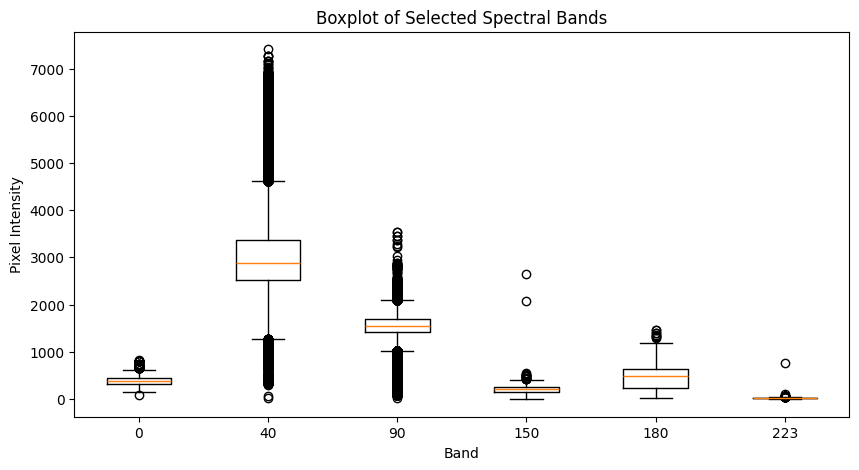

In [37]:
sample_bands = [0, 40, 90, 150, 180, 223]
data = [hsi_sa[:, :, b].flatten() for b in sample_bands]

plt.figure(figsize=(10,5))
plt.boxplot(data, labels=sample_bands)
plt.title("Boxplot of Selected Spectral Bands")
plt.xlabel("Band")
plt.ylabel("Pixel Intensity")
plt.show()

# EDA on SA ground Truth

## Loading GT

In [38]:
mat_sa_gt= sio.loadmat(r'C:\Users\asfia\OneDrive\Desktop\BSC Thesis\HSI-Thesis\data\Salinas_gt.mat')
print(mat_sa_gt.keys())

dict_keys(['__header__', '__version__', '__globals__', 'salinas_gt'])


In [39]:
hsi_sa_gt = mat_sa_gt['salinas_gt']

print(hsi_sa_gt.shape)
print(hsi_sa_gt.dtype)

(512, 217)
uint8


## Visualize Ground Truth

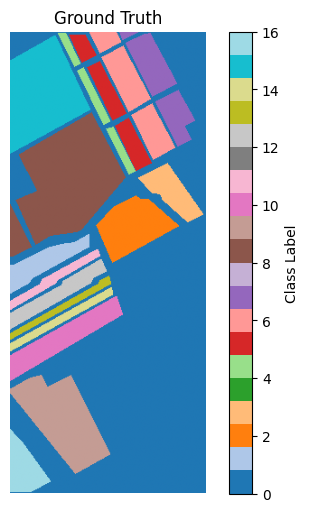

In [40]:
plt.figure(figsize=(6,6))
plt.imshow(hsi_sa_gt, cmap='tab20')
plt.colorbar(label='Class Label')
plt.title("Ground Truth")
plt.axis("off")
plt.show()

## Basic Information

In [41]:
print("Shape:", hsi_sa_gt.shape)
print("Minimum Label:", np.min(hsi_sa_gt))
print("Maximum Label:", np.max(hsi_sa_gt))

classes = np.unique(hsi_sa_gt)

print("Unique Classes:", classes)
print("Number of Classes:", len(classes)-1)   # Excluding background (0)

Shape: (512, 217)
Minimum Label: 0
Maximum Label: 16
Unique Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Number of Classes: 16


## Class Distribution

In [42]:
labels, counts = np.unique(hsi_sa_gt, return_counts=True)

for l, c in zip(labels, counts):
    print(f"Class {l}: {c} pixels")

Class 0: 56975 pixels
Class 1: 2009 pixels
Class 2: 3726 pixels
Class 3: 1976 pixels
Class 4: 1394 pixels
Class 5: 2678 pixels
Class 6: 3959 pixels
Class 7: 3579 pixels
Class 8: 11271 pixels
Class 9: 6203 pixels
Class 10: 3278 pixels
Class 11: 1068 pixels
Class 12: 1927 pixels
Class 13: 916 pixels
Class 14: 1070 pixels
Class 15: 7268 pixels
Class 16: 1807 pixels


## Bar Chart of Class Distribution

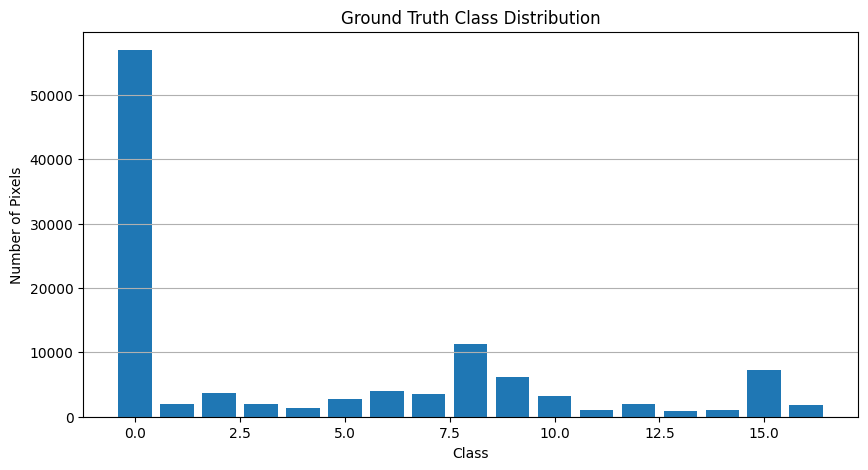

In [43]:
plt.figure(figsize=(10,5))

plt.bar(labels, counts)

plt.xlabel("Class")
plt.ylabel("Number of Pixels")
plt.title("Ground Truth Class Distribution")
plt.grid(axis='y')
plt.show()

## Pie Chart

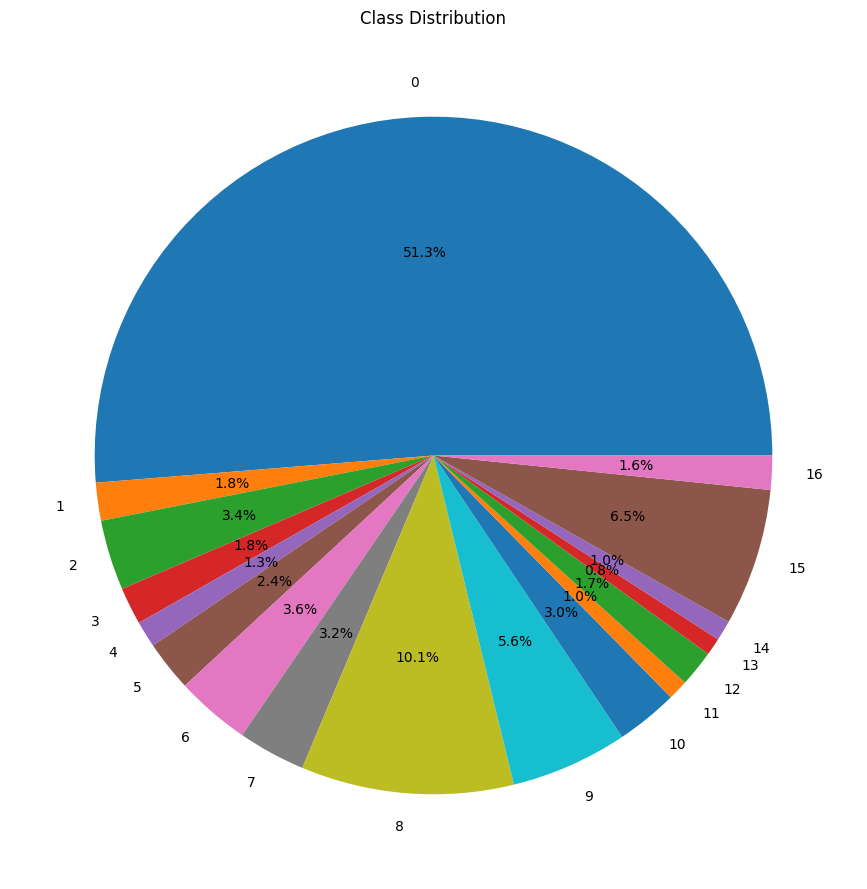

In [44]:
plt.figure(figsize=(11,11))

plt.pie(counts,labels=labels,autopct='%1.1f%%')

plt.title("Class Distribution")
plt.show()

## Background vs Labeled Pixels

In [45]:
background = np.sum(hsi_sa_gt == 0)
labeled = np.sum(hsi_sa_gt > 0)

print("Background Pixels:", background)
print("Labeled Pixels:", labeled)

Background Pixels: 56975
Labeled Pixels: 54129


## Heatmap of Labels

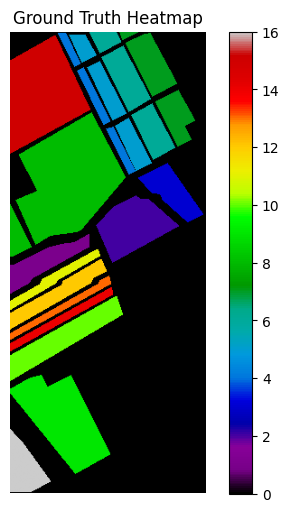

In [46]:
plt.figure(figsize=(6,6))

plt.imshow(hsi_sa_gt, cmap='nipy_spectral')

plt.title("Ground Truth Heatmap")
plt.colorbar()
plt.axis("off")
plt.show()

## Class Imbalance

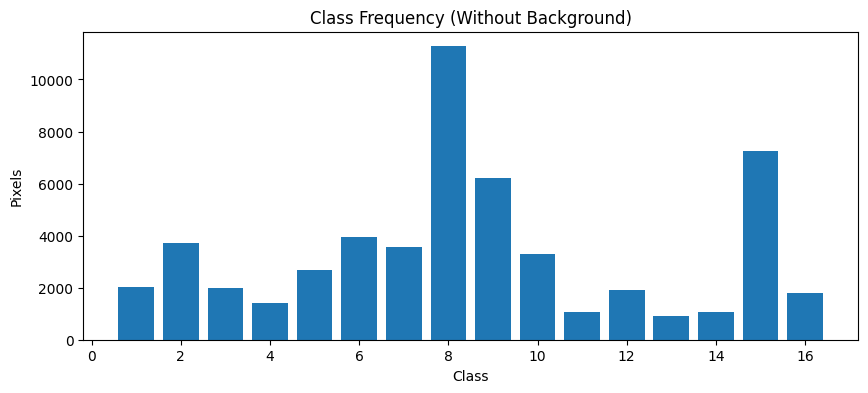

In [47]:
counts_no_bg = counts[labels != 0]
labels_no_bg = labels[labels != 0]

plt.figure(figsize=(10,4))

plt.bar(labels_no_bg, counts_no_bg)

plt.xlabel("Class")
plt.ylabel("Pixels")
plt.title("Class Frequency (Without Background)")
plt.show()

## Percentage of Each Class

In [48]:
labels, counts = np.unique(hsi_sa_gt, return_counts=True)

total = np.sum(counts)

for l, c in zip(labels, counts):
    print(f"Class {l}: {100*c/total:.2f}%")

Class 0: 51.28%
Class 1: 1.81%
Class 2: 3.35%
Class 3: 1.78%
Class 4: 1.25%
Class 5: 2.41%
Class 6: 3.56%
Class 7: 3.22%
Class 8: 10.14%
Class 9: 5.58%
Class 10: 2.95%
Class 11: 0.96%
Class 12: 1.73%
Class 13: 0.82%
Class 14: 0.96%
Class 15: 6.54%
Class 16: 1.63%


# Overlay Ground Truth on SA False RGB

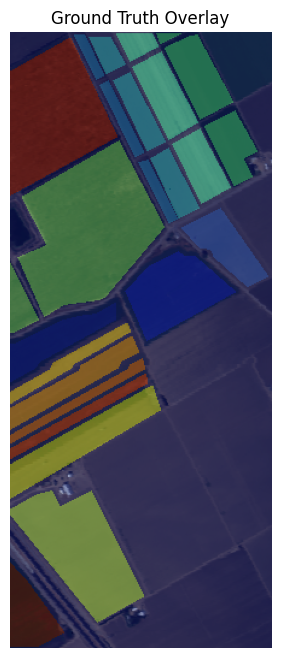

In [49]:
rgb = hsi_sa[:, :, [30, 20, 10]]
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.imshow(hsi_sa_gt, cmap='jet', alpha=0.35)
plt.title("Ground Truth Overlay")
plt.axis("off")
plt.show()